# Exploratory Data Analysis (EDA)

## Тема исследования
Влияние методов предобработки данных на качество моделей машинного обучения и нейросетей.

## Цель этапа
Провести предварительный анализ данных (EDA), изучить структуру датасета, определить наличие пропущенных значений, исследовать распределение классов и признаки, а также подготовить данные для дальнейшего построения моделей машинного обучения.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

# настройки отображения
pd.set_option("display.max_columns", None)

# стиль графиков
sns.set_style("whitegrid")

## Загрузка датасета adult-census

В исследовании используется датасет adult-census, содержащий информацию о возрасте, образовании, профессии, рабочем времени и других характеристиках людей.

Целевая переменная:
- `<=50K` — доход менее либо равен 50 000 долларов;
- `>50K` — доход более 50 000 долларов.

Датасет используется для задачи бинарной классификации.

In [3]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "target"
]

df = pd.read_csv(
    "../data/raw/adult-census.csv",
    na_values="?",
    skipinitialspace=True
)

df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
print("Размер датасета:", df.shape)

Размер датасета: (48842, 14)


## Анализ структуры данных

На данном этапе анализируются:
- количество объектов и признаков;
- типы данных;
- наличие пропусков;
- общая структура датасета.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   education       48842 non-null  str  
 3   education-num   48842 non-null  int64
 4   marital-status  48842 non-null  str  
 5   occupation      46033 non-null  str  
 6   relationship    48842 non-null  str  
 7   race            48842 non-null  str  
 8   sex             48842 non-null  str  
 9   capital-gain    48842 non-null  int64
 10  capital-loss    48842 non-null  int64
 11  hours-per-week  48842 non-null  int64
 12  native-country  47985 non-null  str  
 13  class           48842 non-null  str  
dtypes: int64(5), str(9)
memory usage: 5.2 MB


## Анализ пропущенных значений

Пропущенные значения являются одной из ключевых проблем при обучении моделей машинного обучения.


In [6]:

missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_table

,missing_count,missing_percent
occupation,2809,5.751198
workclass,2799,5.730724
native-country,857,1.754637
age,0,0.000000
education-num,0,0.000000
education,0,0.000000
marital-status,0,0.000000
relationship,0,0.000000
sex,0,0.000000
race,0,0.000000


In [7]:
df["class"].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [8]:
df["class"].value_counts(normalize=True) * 100

class
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

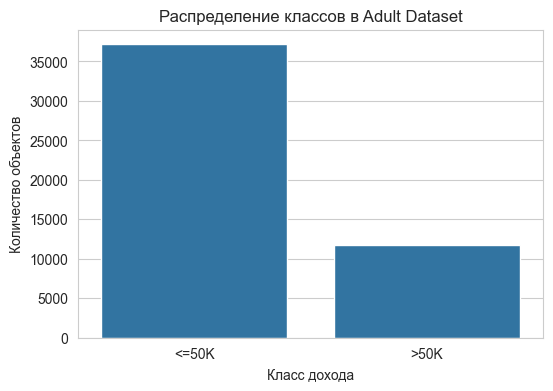

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="class")

plt.title("Распределение классов в Adult Dataset")
plt.xlabel("Класс дохода")
plt.ylabel("Количество объектов")

plt.show()

### Вывод

В датасете наблюдается дисбаланс классов:
количество объектов класса `<=50K` существенно превышает количество объектов класса `>50K`.

Это делает задачу подходящей для исследования методов балансировки данных, таких как:
- `class_weight`;
- `SMOTE`.

In [9]:

numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

categorical_features.remove("class")

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Числовые признаки: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Категориальные признаки: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


C:\Users\vdohn\AppData\Local\Temp\ipykernel_22952\2553250337.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


In [10]:
df[numeric_features].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


## Визуализация пропущенных значений

### Heatmap пропусков

Тепловая карта позволяет визуально оценить:
- наличие пропусков;
- концентрацию пропущенных значений;
- распределение пропусков по объектам и признакам.

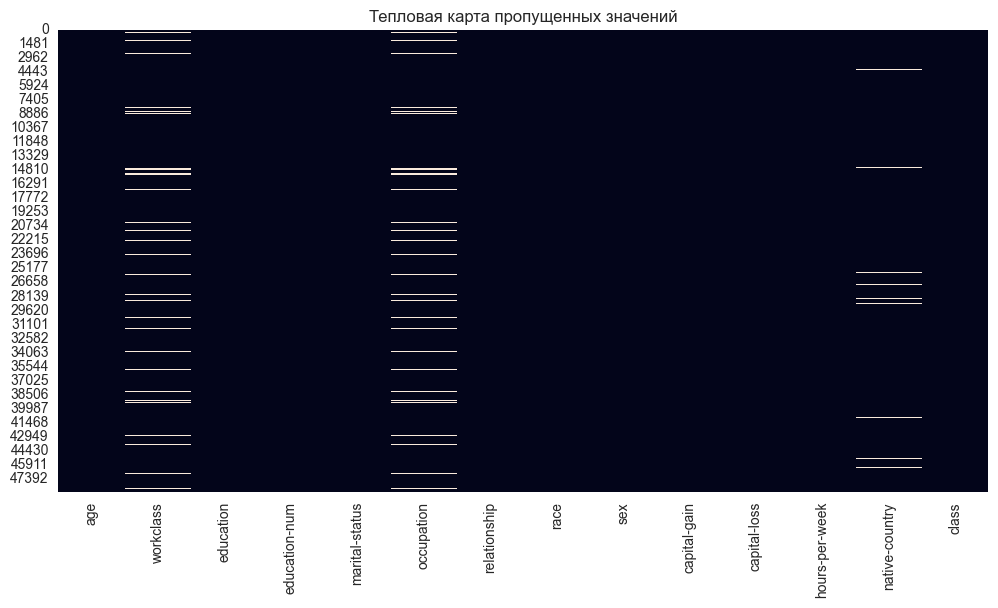

In [11]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isna(), cbar=False)

plt.title("Тепловая карта пропущенных значений")

plt.show()

На тепловой карте видно, что пропуски сосредоточены в нескольких категориальных признаках: `occupation`, `workclass` и `native-country`. Числовые признаки не содержат пропущенных значений.

### Гистограмма возраста

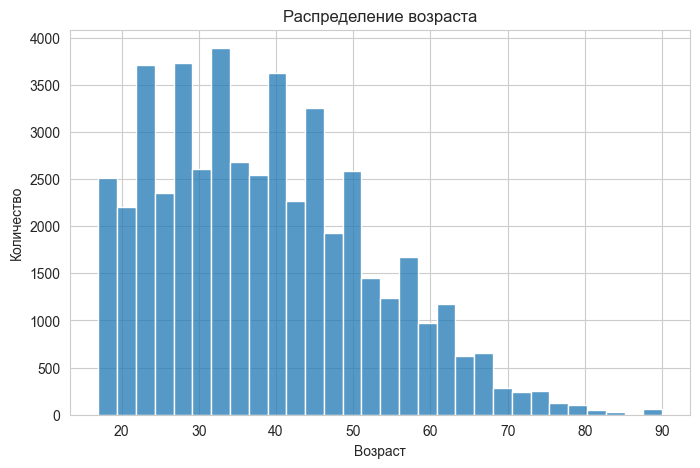

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=30)

plt.title("Распределение возраста")
plt.xlabel("Возраст")
plt.ylabel("Количество")

plt.show()

Распределение возраста смещено: основная часть наблюдений относится к людям молодого и среднего возраста. Медианный возраст составляет около 37 лет, а старшие возрасты встречаются реже.

### График hours-per-week

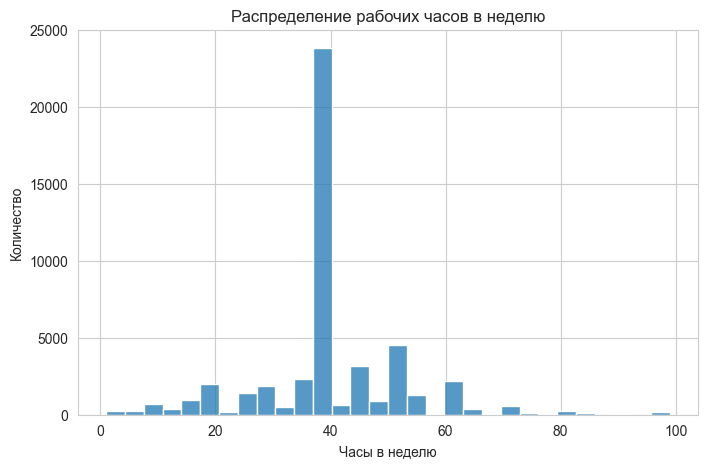

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["hours-per-week"], bins=30)

plt.title("Распределение рабочих часов в неделю")
plt.xlabel("Часы в неделю")
plt.ylabel("Количество")

plt.show()

Распределение рабочих часов имеет выраженный пик около 40 часов в неделю, что соответствует стандартной полной занятости. При этом присутствуют наблюдения с меньшей и значительно большей нагрузкой.

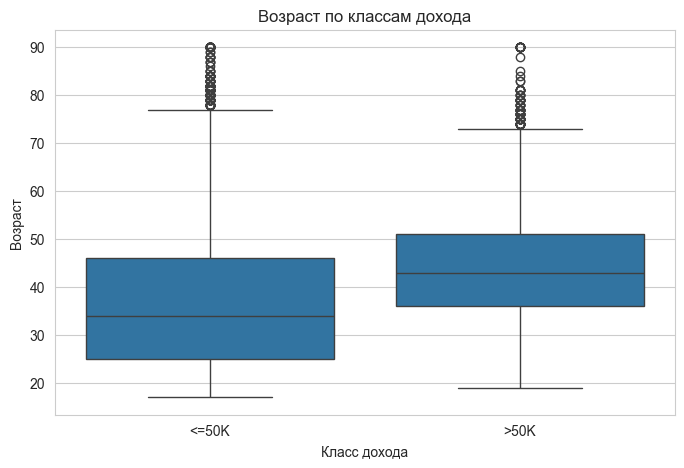

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="class", y="age")

plt.title("Возраст по классам дохода")
plt.xlabel("Класс дохода")
plt.ylabel("Возраст")

plt.show()



Для класса `>50K` возраст в среднем выше, чем для класса `<=50K`: медиана составляет примерно 43 года против 34 лет. Это указывает на связь дохода с возрастом и, вероятно, накопленным профессиональным опытом.

Точки над верхними границами boxplot представляют собой выбросы — редкие значения возраста, существенно отличающиеся от основной массы наблюдений. Наличие выбросов является важной характеристикой данных, поскольку некоторые модели машинного обучения и методы масштабирования чувствительны к экстремальным значениям признаков.

## Корреляционный анализ

Корреляционный анализ используется для изучения взаимосвязей между числовыми признаками.

Высокая корреляция может влиять на работу некоторых моделей машинного обучения.

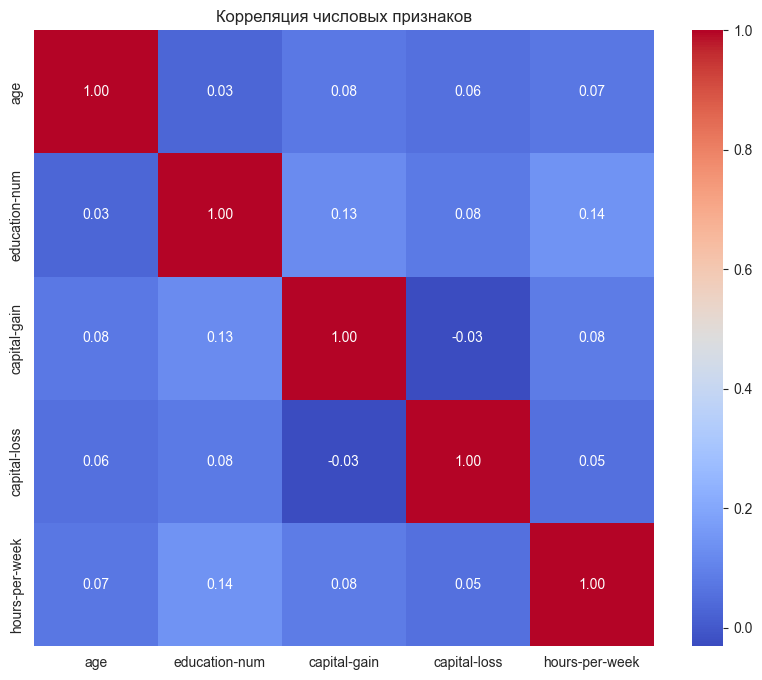

In [15]:
plt.figure(figsize=(10, 8))

correlation_matrix = df[numeric_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Корреляция числовых признаков")

plt.show()

### Интерпретация результатов

Корреляционный анализ был проведён для изучения взаимосвязей между числовыми признаками датасета.

Корреляционный анализ показал отсутствие сильных линейных зависимостей между большинством числовых признаков датасета.

Наблюдаются лишь слабые и умеренные корреляции между отдельными признаками, что снижает риск выраженной мультиколлинеарности.

Несмотря на отсутствие сильной мультиколлинеарности, наличие умеренно коррелирующих признаков подтверждает необходимость анализа чувствительности моделей к различным методам предобработки данных, включая:
- масштабирование признаков;
- обработку пропусков;
- балансировку классов.

Корреляционный анализ позволяет лучше понять структуру данных перед построением вычислительного эксперимента и обучением моделей машинного обучения.

# Общие выводы по этапу EDA

В ходе предварительного анализа данных были исследованы структура датасета, распределение признаков и наличие пропущенных значений.

Основные выводы:
- датасет содержит как числовые, так и категориальные признаки;
- в ряде категориальных признаков присутствуют пропущенные значения;
- наблюдается дисбаланс классов целевой переменной;
- числовые признаки имеют неоднородные распределения и содержат выбросы;
- существенной мультиколлинеарности между большинством числовых признаков не выявлено.

Полученные результаты подтверждают необходимость исследования влияния методов предобработки данных на качество моделей машинного обучения.